In [3]:
import pandas as pd

df = pd.read_csv("../data/bpi-challenge-2017/bpi_2017_cleaned.csv")

# convert timestamp
df["time:timestamp"] = pd.to_datetime(
    df["time:timestamp"],
    format="mixed",
    utc=True
)

# sort đúng thứ tự
df = df.sort_values(by=["case:concept:name", "time:timestamp"])

In [4]:
import pm4py

log = pm4py.format_dataframe(
    df,
    case_id='case:concept:name',
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

In [6]:
import pm4py

net, im, fm = pm4py.discover_petri_net_inductive(log)

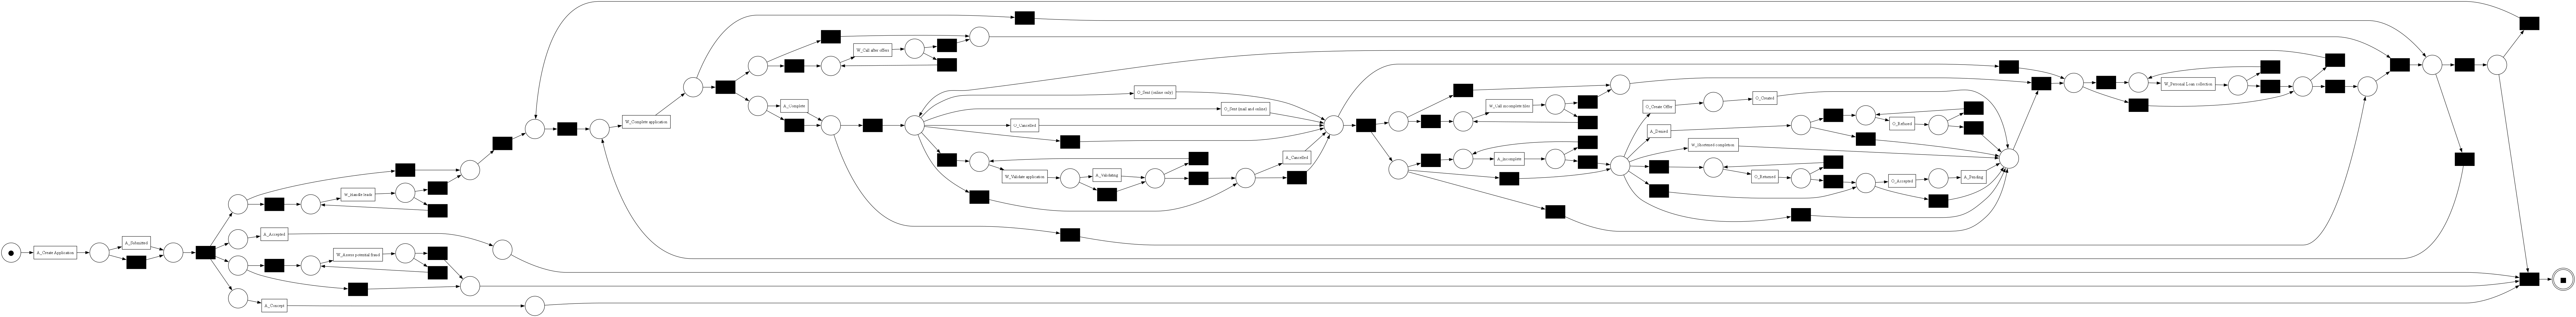

In [7]:
from pm4py.visualization.petri_net import visualizer as pn_vis

gviz = pn_vis.apply(net, im, fm)
pn_vis.view(gviz)

In [23]:
print("Cases:", df["case:concept:name"].nunique())
print("Events:", len(df))
print("Activities:", df["concept:name"].nunique())

Cases: 31509
Events: 1202267
Activities: 26


In [24]:
import numpy as np

durations = pm4py.get_all_case_durations(log)

print("Mean:", np.mean(durations))
print("Min:", np.min(durations))
print("Max:", np.max(durations))

Mean: 1892125.923069948
Min: 201.062
Max: 24716658.654


In [25]:
variants = pm4py.get_variants(log)

print("Number of variants:", len(variants))

Number of variants: 15930


In [28]:
df["concept:name"].value_counts().head(50)

concept:name
W_Validate application        209496
W_Call after offers           191092
W_Call incomplete files       168529
W_Complete application        148900
W_Handle leads                 47264
O_Create Offer                 42995
O_Created                      42995
O_Sent (mail and online)       39707
A_Validating                   38816
A_Accepted                     31509
A_Create Application           31509
A_Concept                      31509
A_Complete                     31362
O_Returned                     23305
A_Incomplete                   23055
O_Cancelled                    20898
A_Submitted                    20423
O_Accepted                     17228
A_Pending                      17228
A_Cancelled                    10431
O_Refused                       4695
A_Denied                        3753
W_Assess potential fraud        3282
O_Sent (online only)            2026
W_Shortened completion           238
W_Personal Loan collection        22
Name: count, dtype: int64

In [10]:
import pm4py

aligned_traces = pm4py.conformance_diagnostics_alignments(
    log, net, im, fm
)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
aligning log, completed variants :: 100%|██████████| 15930/15930 [15:36:32<00:00,  3.53s/it]   


In [12]:
costs = [x["cost"] for x in aligned_traces]

avg_cost = sum(costs) / len(costs)
print("Average cost:", avg_cost)
not_fit = sum(1 for x in aligned_traces if x["cost"] > 0)

print("Non-fitting traces:", not_fit)
print("Total traces:", len(aligned_traces))
worst = max(aligned_traces, key=lambda x: x["cost"])
print("Worst cost:", worst["cost"])
for move in worst["alignment"]:
    print(move)
    

Average cost: 86.5110285950046
Non-fitting traces: 31509
Total traces: 31509
Worst cost: 329
('A_Create Application', 'A_Create Application')
('>>', None)
('>>', None)
('>>', None)
('>>', None)
('>>', None)
('W_Complete application', 'W_Complete application')
('>>', None)
('>>', None)
('W_Complete application', 'W_Complete application')
('>>', None)
('>>', None)
('A_Concept', 'A_Concept')
('W_Complete application', 'W_Complete application')
('>>', None)
('>>', None)
('W_Complete application', 'W_Complete application')
('>>', None)
('>>', None)
('>>', None)
('A_Accepted', 'A_Accepted')
('>>', None)
('>>', None)
('>>', None)
('>>', None)
('>>', None)
('O_Create Offer', 'O_Create Offer')
('O_Created', 'O_Created')
('>>', None)
('>>', None)
('>>', None)
('O_Sent (mail and online)', 'O_Sent (mail and online)')
('>>', None)
('>>', None)
('>>', None)
('>>', None)
('>>', None)
('W_Complete application', 'W_Complete application')
('>>', None)
('>>', None)
('W_Call after offers', 'W_Call after o

In [13]:
from collections import Counter

deviations = Counter()

for trace in aligned_traces:
    for log_move, model_move in trace["alignment"]:
        if log_move == ">>" or model_move == ">>":
            deviations[(log_move, model_move)] += 1

print(deviations.most_common(10))

[(('>>', None), 2725876)]


In [22]:
print(df["concept:name"].unique()[:20])

['A_Create Application' 'A_Submitted' 'W_Handle leads'
 'W_Complete application' 'A_Concept' 'A_Accepted' 'O_Create Offer'
 'O_Created' 'O_Sent (mail and online)' 'W_Call after offers' 'A_Complete'
 'A_Cancelled' 'O_Cancelled' 'W_Validate application' 'A_Validating'
 'O_Returned' 'O_Accepted' 'A_Pending' 'W_Call incomplete files'
 'A_Incomplete']


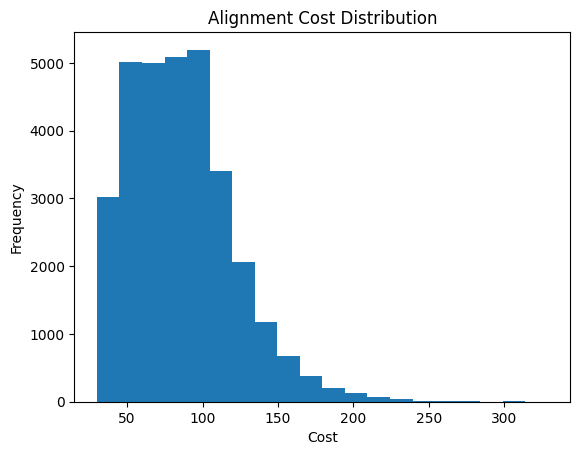

In [14]:
import matplotlib.pyplot as plt

plt.hist(costs, bins=20)
plt.title("Alignment Cost Distribution")
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.show()

In [15]:
import pm4py

durations = pm4py.get_all_case_durations(log)

print("Average duration:", sum(durations) / len(durations))

Average duration: 1892125.9230699483


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pm4py\algo\discovery\performance_spectrum\variants\dataframe.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[activity_key] = dataframe[activity_key].astype("string")


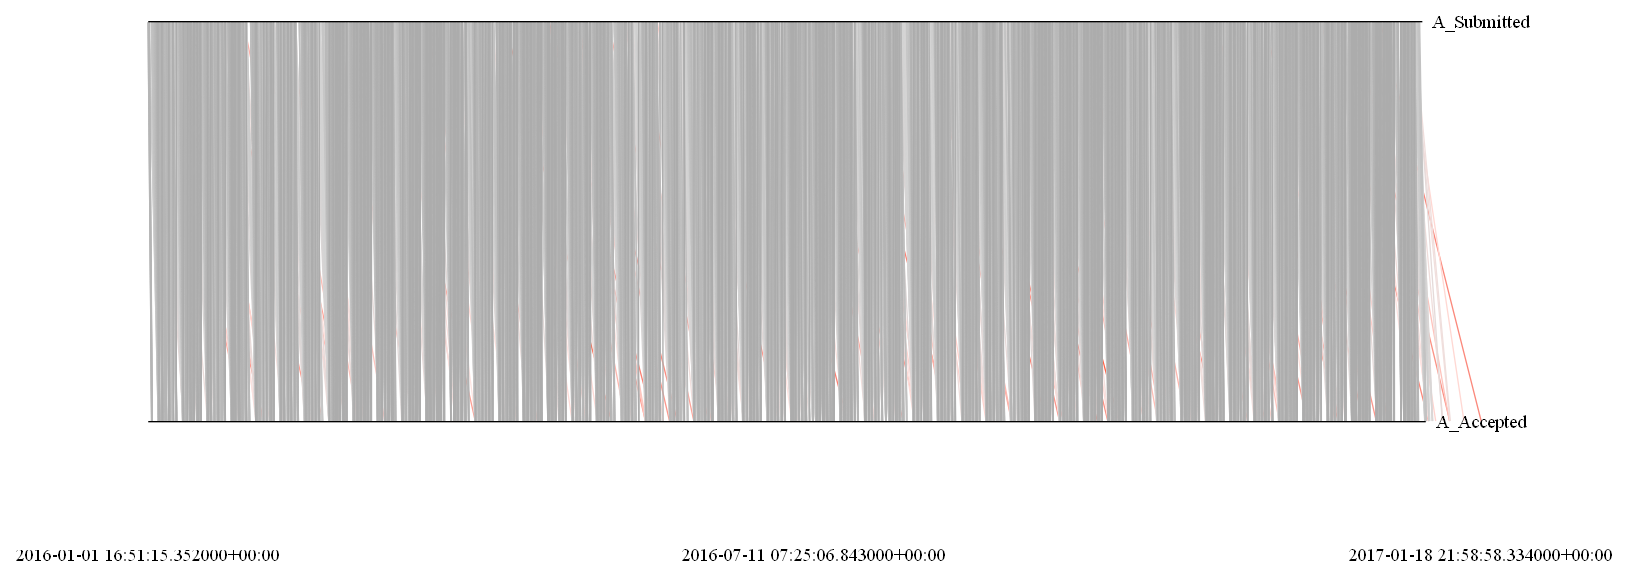

In [16]:
import pm4py

pm4py.view_performance_spectrum(
    log,
    activities=["A_Submitted", "A_Accepted"]
)

In [ ]:
from pm4py.statistics.attributes.log import get

durations = get.get_attribute_values(log, "concept:name")
print(durations)

{'A_Create Application': 31509, 'A_Submitted': 20423, 'A_Concept': 31509, 'A_Accepted': 31509, 'O_Create Offer': 42995, 'O_Created': 42995, 'O_Sent (mail and online)': 39707, 'A_Complete': 31362, 'A_Cancelled': 10431, 'O_Cancelled': 20898, 'W_Complete application': 19104, 'A_Validating': 38816, 'O_Returned': 23305, 'O_Accepted': 17228, 'A_Pending': 17228, 'W_Validate application': 15848, 'A_Incomplete': 23055, 'A_Denied': 3753, 'O_Refused': 4695, 'W_Call incomplete files': 2793, 'W_Handle leads': 3493, 'O_Sent (online only)': 2026, 'W_Assess potential fraud': 282, 'W_Call after offers': 342}


In [19]:
import pm4py

sna_res = pm4py.discover_handover_of_work_network(log)
pm4py.view_sna(sna_res)

In [ ]:
df = df[df["lifecycle:transition"] == "complete"]
log = pm4py.format_dataframe(
    df,
    case_id="case:concept:name",
    activity_key="concept:name",
    timestamp_key="time:timestamp"
)



aligning log, completed variants :: 100%|██████████| 5623/5623 [07:00<00:00, 13.36it/s]


In [37]:
noise_activities = [
    "W_Call incomplete files",
    "W_Call after offers"
]

df = df[~df["concept:name"].isin(noise_activities)]

In [38]:
valid_end = ["A_Complete", "A_Cancelled", "A_Denied"]

completed_cases = df[df["concept:name"].isin(valid_end)]["case:concept:name"].unique()

df = df[df["case:concept:name"].isin(completed_cases)]

In [39]:
df = df.sort_values(["case:concept:name", "time:timestamp"])

df["prev_activity"] = df.groupby("case:concept:name")["concept:name"].shift(1)

df = df[df["concept:name"] != df["prev_activity"]]

df = df.drop(columns=["prev_activity"])

In [41]:
import pm4py

log = pm4py.format_dataframe(
    df,
    case_id="case:concept:name",
    activity_key="concept:name",
    timestamp_key="time:timestamp"
)

variants = pm4py.get_variants(log)

# sắp xếp theo frequency
variants_sorted = sorted(
    variants.items(),
    key=lambda x: x[1],   # dùng trực tiếp count
    reverse=True
)

# giữ top variant
top_variants = [v[0] for v in variants_sorted[:10]]

log = pm4py.filter_variants(log, top_variants)

In [42]:
net, im, fm = pm4py.discover_petri_net_inductive(log)
aligned_traces = pm4py.conformance_diagnostics_alignments(
    log, net, im, fm
)
costs = [x["cost"] for x in aligned_traces]

print("Average cost:", sum(costs)/len(costs))
print("Non-fitting traces:", sum(1 for x in costs if x > 0))
print("Total traces:", len(costs))

aligning log, completed variants :: 100%|██████████| 10/10 [00:00<00:00, 248.67it/s]

Average cost: 2.1770158477025814
Non-fitting traces: 10033
Total traces: 10033


In [45]:
for trace in aligned_traces[:10]:
    print(trace["alignment"])

[('A_Create Application', 'A_Create Application'), ('A_Submitted', 'A_Submitted'), ('>>', None), ('A_Concept', 'A_Concept'), ('A_Accepted', 'A_Accepted'), ('O_Create Offer', 'O_Create Offer'), ('O_Created', 'O_Created'), ('O_Sent (mail and online)', 'O_Sent (mail and online)'), ('>>', None), ('A_Complete', 'A_Complete'), ('A_Cancelled', 'A_Cancelled'), ('O_Cancelled', 'O_Cancelled')]
[('A_Create Application', 'A_Create Application'), ('A_Submitted', 'A_Submitted'), ('>>', None), ('A_Concept', 'A_Concept'), ('A_Accepted', 'A_Accepted'), ('O_Create Offer', 'O_Create Offer'), ('O_Created', 'O_Created'), ('O_Sent (mail and online)', 'O_Sent (mail and online)'), ('W_Complete application', 'W_Complete application'), ('A_Complete', 'A_Complete'), ('>>', None), ('A_Validating', 'A_Validating'), ('>>', None), ('O_Returned', 'O_Returned'), ('O_Accepted', 'O_Accepted'), ('A_Pending', 'A_Pending')]
[('A_Create Application', 'A_Create Application'), ('>>', None), ('A_Concept', 'A_Concept'), ('A_Acc

In [46]:
variants = pm4py.get_variants(log)

variants_sorted = sorted(variants.items(), key=lambda x: x[1], reverse=True)

for v, count in variants_sorted[:10]:
    print(count, v)

2228 ('A_Create Application', 'A_Submitted', 'A_Concept', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application', 'A_Complete', 'A_Cancelled', 'O_Cancelled')
1934 ('A_Create Application', 'A_Submitted', 'A_Concept', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'A_Complete', 'A_Cancelled', 'O_Cancelled')
1595 ('A_Create Application', 'A_Concept', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application', 'A_Complete', 'A_Cancelled', 'O_Cancelled')
971 ('A_Create Application', 'A_Concept', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application', 'A_Complete', 'A_Validating', 'O_Returned', 'O_Accepted', 'A_Pending')
676 ('A_Create Application', 'A_Submitted', 'A_Concept', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'A_Complete', 'A_Validating', 'O_Returned', 'O_Accepted', 'A_Pending')
621 ('A_Create Applicatio

In [49]:
df_sorted = df.sort_values(["case:concept:name", "time:timestamp"])

# thời gian event tiếp theo
df_sorted["next_time"] = df_sorted.groupby("case:concept:name")["time:timestamp"].shift(-1)

# duration giữa 2 activity
df_sorted["duration"] = (
    df_sorted["next_time"] - df_sorted["time:timestamp"]
).dt.total_seconds()

# trung bình theo activity
duration_per_activity = df_sorted.groupby("concept:name")["duration"].mean()

# sắp xếp giảm dần
duration_per_activity = duration_per_activity.sort_values(ascending=False)

print(duration_per_activity.head(10))

concept:name
A_Complete                  1.143214e+06
O_Sent (online only)        3.730233e+05
O_Cancelled                 3.141004e+05
A_Incomplete                2.987596e+05
O_Returned                  1.804658e+05
O_Sent (mail and online)    1.411105e+05
A_Concept                   1.224699e+05
W_Assess potential fraud    1.119443e+05
A_Validating                4.255069e+04
A_Accepted                  9.439132e+03
Name: duration, dtype: float64


In [43]:
from pm4py.algo.evaluation.replay_fitness import algorithm as fitness

fit = fitness.apply(log, net, im, fm)
print(fit)

aligning log, completed variants :: 100%|██████████| 10/10 [00:00<00:00, 290.45it/s]

{'percFitTraces': 100.0, 'averageFitness': 1.0, 'percentage_of_fitting_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 0.9999893003231684}


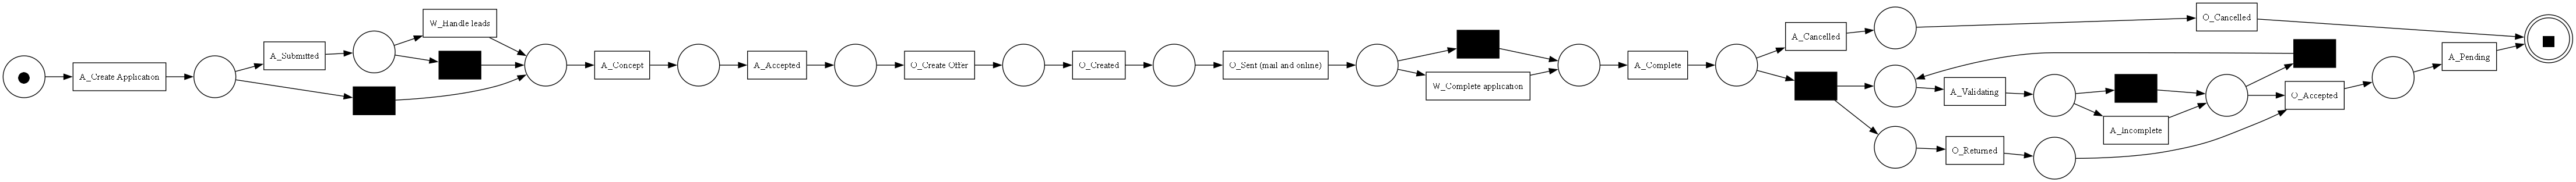

In [44]:
pm4py.view_petri_net(net, im, fm)

In [35]:
from sklearn.tree import DecisionTreeClassifier

features = df[["CreditScore", "case:RequestedAmount"]].fillna(0)
target = df["Accepted"].fillna(False)

model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=100,
    min_samples_leaf=50,
    criterion="entropy",
    class_weight="balanced",
    random_state=42
)
model.fit(features, target)

C:\Users\Admin\AppData\Local\Temp\ipykernel_1564\392793519.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target = df["Accepted"].fillna(False)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [36]:
from sklearn.tree import export_text

rules = export_text(model, feature_names=list(features.columns))
print(rules)

|--- CreditScore <= 703.50
|   |--- case:RequestedAmount <= 8479.00
|   |   |--- case:RequestedAmount <= 4500.00
|   |   |   |--- class: False
|   |   |--- case:RequestedAmount >  4500.00
|   |   |   |--- class: False
|   |--- case:RequestedAmount >  8479.00
|   |   |--- CreditScore <= 296.00
|   |   |   |--- class: False
|   |   |--- CreditScore >  296.00
|   |   |   |--- class: False
|--- CreditScore >  703.50
|   |--- CreditScore <= 830.50
|   |   |--- case:RequestedAmount <= 11450.00
|   |   |   |--- class: True
|   |   |--- case:RequestedAmount >  11450.00
|   |   |   |--- class: True
|   |--- CreditScore >  830.50
|   |   |--- case:RequestedAmount <= 9950.00
|   |   |   |--- class: True
|   |   |--- case:RequestedAmount >  9950.00
|   |   |   |--- class: True

